# H9 -- Spatial epidemiology core

Fits a real count model of dengue admissions against real predictors, with a
population offset, and checks whether the model's residuals are still spatially
autocorrelated -- the H9 "done when" gate in `PLAN.md`.

## Scope adjustment, decided from evidence (read this first)

PLAN.md's H9 asks for **ward-level** dengue counts. Those do not exist publicly.
The only real, current, public dengue counts are on the DGHS HEOC dashboard, and
the finest geography it publishes is **10 reporting units**: 7 divisions, with
Dhaka division split into "Dhaka (Out of CC)", DNCC and DSCC (checked directly --
no district, upazila or ward breakdown anywhere on the page). Fabricating or
disaggregating to wards would break this project's rule of only using real data,
so H9 runs on what exists:

- **Unit of analysis: the 8 administrative divisions** (Dhaka = Out of CC + DNCC +
  DSCC), because I could only obtain boundary polygons for divisions (geoBoundaries
  ADM1). I tried to get separate DNCC/DSCC polygons to keep all 10 units and could
  not: Nominatim returns only office buildings for both names (English and Bengali),
  and two OpenStreetMap Overpass queries for administrative relations named
  "Dhaka North/South" returned zero relations. Guessing thana-to-corporation
  membership from ADM3 was rejected as error-prone.
- **n = 8.** That is the single most important fact in this notebook. It allows one
  or two predictors, gives Moran's I very little power, and makes a spatial
  random-effects model (BYM / R-INLA -- the PLAN's "intro R-INLA") statistically
  inappropriate: it would add more latent parameters than there are data points.
  That is why INLA is not run here rather than run and over-read.
- The H4/H8 predictor table covers 3 districts of one division. It cannot be joined
  to national division-level counts, and this notebook does not pretend otherwise.
  Division-level predictors (population, water occurrence) are built here from
  national layers instead.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import rasterstats

from src.dghs import to_divisions
from src.epi import (
    crude_incidence, dispersion, fit_count_model, fit_negbin_mle,
    irr_table, queen_weights, residual_moran, standardize,
)

ROOT = Path('..')
SNAPSHOT = ROOT / 'data/snapshots/dghs_dengue_units_2026-09-20.csv'
ADM1 = ROOT / 'data/raw/bgd_adm1.geojson'                       # scripts/fetch_boundaries.py --level ADM1
POP_TIF = ROOT / 'data/raw/bgd_worldpop_2020_constrained.tif'   # scripts/fetch_population.py
WATER_TIF = ROOT / 'data/raw/bgd_jrc_water_occurrence.tif'      # scripts/fetch_jrc_water.py

## 1. Real dengue counts and real boundaries

`scripts/fetch_dengue_dghs.py` snapshots the DGHS dashboard to a dated CSV (the
dashboard shows year-to-date totals and keeps no history, so an unrecorded run
would not be reproducible). These are **admitted (hospitalised) cases, 1 Jan to
2026-09-20** -- not infections, not incidence.

Three name mismatches between DGHS and geoBoundaries had to be reconciled before
the join (Barishal/Barisal, Chattogram/Chittagong, and geoBoundaries' own typo
"Rajshani" for Rajshahi); `to_divisions` does it, unit-tested, and the assert below
makes the join fail loudly rather than silently drop a division.

In [2]:
units = pd.read_csv(SNAPSHOT, index_col='unit')
print(units.to_string())
print('total admitted cases:', f"{units['cases'].sum():,}", ' deaths:', units['deaths'].sum())

divisions = to_divisions(units)

adm1 = gpd.read_file(ADM1)[['shapeName', 'geometry']]
assert set(adm1['shapeName']) == set(divisions.index), 'division names do not match the boundary file'
adm1 = adm1.set_index('shapeName').loc[divisions.index]
adm1.index.name = 'division'
adm1 = adm1.reset_index()
assert divisions['cases'].sum() == units['cases'].sum()   # merging Dhaka lost/added nothing

                   cases  deaths
unit                            
Barishal            8467      13
Chattogram          8672      16
Dhaka (Out of CC)   9997      10
DNCC                6980      23
DSCC                7317      53
Khulna              9903      32
Mymensingh          3366      18
Rajshahi            3638       8
Rangpur             1762       4
Sylhet               277       1
total admitted cases: 60,379  deaths: 178


## 2. Real predictors per division

Two predictors, **chosen before looking at any model output** and limited to two
because n = 8:

- **Population density** (WorldPop 2020 constrained, people/km2, log-transformed):
  the urbanisation / *Aedes aegypti* habitat-and-crowding proxy. Also gives each
  division's population for the offset.
- **Mean JRC surface-water occurrence** (% of observations that were water,
  1984-2020, Planetary Computer `jrc-gsw`): a stagnant/seasonal-water exposure
  proxy. 255 in this raster is *nodata*, not a value -- averaging it in gave
  impossible values above 100 during development, so it is read with nearest
  resampling and 255 declared as nodata (see `scripts/fetch_jrc_water.py`).

Caveat that applies to both: these are 2020-era / long-run layers, matched to
2026 admissions.

In [3]:
adm1['population'] = [z['sum'] for z in rasterstats.zonal_stats(adm1, str(POP_TIF), stats=['sum'])]
water = rasterstats.zonal_stats(adm1, str(WATER_TIF), stats=['mean', 'min', 'max', 'count'], nodata=255)
adm1['water_occ'] = [z['mean'] for z in water]
adm1['area_km2'] = adm1.to_crs(32646).area / 1e6
adm1['density'] = adm1['population'] / adm1['area_km2']

# sanity checks -- the JRC bug this guards against is real (see script docstring)
assert all(0 <= z['min'] and z['max'] <= 100 for z in water), 'water occurrence out of 0-100: nodata leaked in'
print(f"total WorldPop population across the 8 divisions: {adm1['population'].sum()/1e6:.1f} M "
      "(BBS 2022 census: ~169.8 M; WorldPop 2020 constrained is an earlier, modelled estimate)")

data = adm1.merge(divisions, left_on='division', right_index=True)
data['incidence'] = crude_incidence(data['cases'], data['population'])
data['z_density'] = standardize(np.log(data['density']))
data['z_water'] = standardize(data['water_occ'])
show = data[['division', 'cases', 'deaths', 'population', 'density', 'water_occ', 'incidence']].round(1)
show['population'] = (show['population'] / 1e6).round(2)
show = show.rename(columns={'population': 'pop (M)', 'density': 'people/km2', 'water_occ': 'water %', 'incidence': 'cases/100k'})
print(show.to_string(index=False))
print()
print('Spearman correlations (n=8):')
print(data[['density', 'water_occ', 'incidence']].corr(method='spearman').round(2))

total WorldPop population across the 8 divisions: 162.2 M (BBS 2022 census: ~169.8 M; WorldPop 2020 constrained is an earlier, modelled estimate)
  division  cases  deaths  pop (M)  people/km2  water %  cases/100k
   Barisal   8467      13     8.05       840.9     13.4       105.2
Chittagong   8672      16    30.80      1010.2      5.0        28.2
     Dhaka  24294      86    45.79      2185.9     10.0        53.1
    Khulna   9903      32    16.29       756.0     11.7        60.8
Mymensingh   3366      18    11.79      1128.6      6.6        28.5
  Rajshani   3638       8    20.49      1102.9      7.1        17.8
   Rangpur   1762       4    17.17      1033.4      3.7        10.3
    Sylhet    277       1    11.80       965.9     14.9         2.3

Spearman correlations (n=8):
           density  water_occ  incidence
density       1.00      -0.48      -0.21
water_occ    -0.48       1.00       0.26
incidence    -0.21       0.26       1.00


## 3. Counts vs. incidence -- why the offset exists

Raw counts mostly rank divisions by how many people live there. Incidence divides
that out, and it changes the story: Dhaka has by far the most admissions but is
mid-table on a per-person basis, while Barisal is highest per person and Sylhet
lowest by a wide margin.

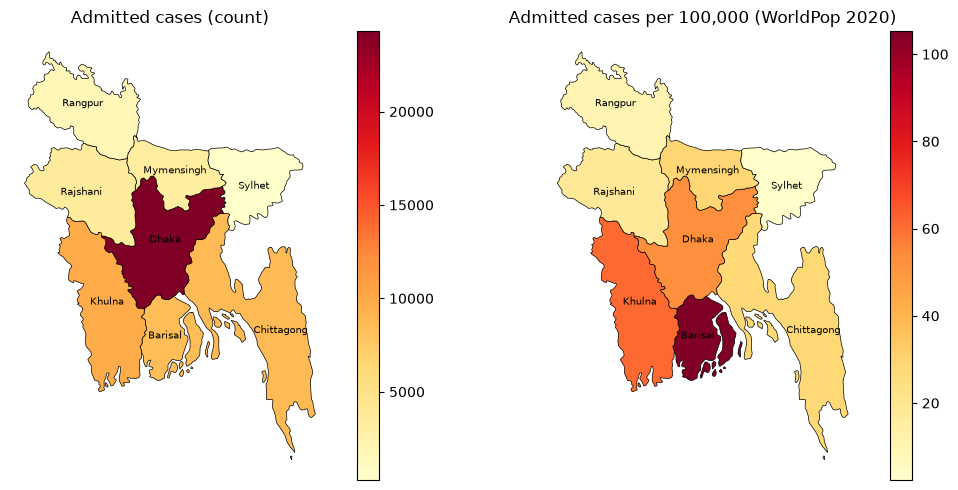

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, col, title in [(axes[0], 'cases', 'Admitted cases (count)'), (axes[1], 'incidence', 'Admitted cases per 100,000 (WorldPop 2020)')]:
    data.plot(column=col, cmap='YlOrRd', legend=True, edgecolor='black', linewidth=0.5, ax=ax)
    for _, r in data.iterrows():
        c = r.geometry.representative_point()
        ax.annotate(r['division'], (c.x, c.y), ha='center', fontsize=7)
    ax.set_title(title); ax.set_axis_off()
plt.tight_layout(); plt.show()

## 4. Is the raw pattern spatially clustered? (Moran's I)

Moran's I on log crude incidence, queen contiguity on the geoBoundaries polygons
(same source file, so shared borders match exactly; every division has >= 2
neighbours), 9,999-permutation p-value. **With 8 units this test has very low
power** -- a non-significant result is not evidence of randomness.

In [5]:
weights = queen_weights(adm1)
print('neighbours:', {adm1.loc[i, 'division']: [adm1.loc[j, 'division'] for j in ns] for i, ns in weights.neighbors.items()})
moran_crude = residual_moran(np.log(data['incidence'].values), weights)
print(f"Moran's I of log crude incidence = {moran_crude.I:.3f}  (expected under no autocorrelation {moran_crude.EI:.3f}),  permutation p = {moran_crude.p_sim:.4f}")

neighbours: {'Barisal': ['Dhaka', 'Khulna'], 'Chittagong': ['Dhaka', 'Sylhet'], 'Dhaka': ['Barisal', 'Chittagong', 'Khulna', 'Mymensingh', 'Rajshani', 'Sylhet'], 'Khulna': ['Barisal', 'Dhaka', 'Rajshani'], 'Mymensingh': ['Dhaka', 'Rajshani', 'Rangpur', 'Sylhet'], 'Rajshani': ['Dhaka', 'Khulna', 'Mymensingh', 'Rangpur'], 'Rangpur': ['Mymensingh', 'Rajshani'], 'Sylhet': ['Chittagong', 'Dhaka', 'Mymensingh']}
Moran's I of log crude incidence = 0.076  (expected under no autocorrelation -0.143),  permutation p = 0.1445


## 5. Poisson first -- and why it fails here

A Poisson GLM with a `log(population)` offset is the textbook model for counts, so
it is fitted first. Its assumption is variance = mean; the **Pearson dispersion**
(chi-square / residual df) tests that. Values near 1 are fine; far above 1 means
the standard errors are far too small.

In [6]:
FORMULAS = {
    'null (rate only)': 'cases ~ 1',
    'density':          'cases ~ z_density',
    'water':            'cases ~ z_water',
    'density + water':  'cases ~ z_density + z_water',
}
rows = []
for name, formula in FORMULAS.items():
    r = fit_count_model(data, formula, 'population', 'poisson')
    row = {'model': name, 'Pearson dispersion': round(dispersion(r))}
    if 'z_water' in r.params: row['Poisson IRR water (95% CI)'] = '%.2f (%.2f-%.2f)' % tuple(irr_table(r).loc['z_water', ['IRR', 'ci_low', 'ci_high']])
    if 'z_density' in r.params: row['Poisson IRR density (95% CI)'] = '%.2f (%.2f-%.2f)' % tuple(irr_table(r).loc['z_density', ['IRR', 'ci_low', 'ci_high']])
    rows.append(row)
pd.DataFrame(rows).fillna('').set_index('model')

,Pearson dispersion,Poisson IRR density (95% CI),Poisson IRR water (95% CI)
model,,,
null (rate only),3675,,
density,4545,1.12 (1.11-1.12),
water,2555,,1.45 (1.44-1.46)
density + water,3105,1.10 (1.09-1.11),1.46 (1.45-1.48)


Dispersion in the **thousands** (should be ~1). The Poisson intervals above are
therefore fantasy -- they look extremely precise (e.g. IRR 1.12, CI 1.11-1.12) only
because the model assumes a variance thousands of times too small. The fix is a
model that lets the variance exceed the mean:

- **Negative binomial (NB2)**: variance = mu + alpha * mu^2, alpha estimated by
  maximum likelihood (it converges here, which I checked rather than assumed).
- **Quasi-Poisson**: same Poisson mean model, standard errors inflated by the
  observed dispersion. Reported alongside as a sensitivity check, since with n = 8
  the NB alpha is itself very uncertain.

Coefficients are **incidence rate ratios (IRR) per 1 SD of the predictor**.

In [7]:
fits = {}
rows = []
for name, formula in FORMULAS.items():
    nb, alpha = fit_negbin_mle(data, formula, 'population')
    qp = fit_count_model(data, formula, 'population', 'quasi-poisson')
    fits[name] = {'nb': nb, 'qp': qp, 'alpha': alpha}
    for label, res in [('negative binomial', nb), ('quasi-Poisson', qp)]:
        t = irr_table(res)
        for term in [t_ for t_ in t.index if t_ != 'Intercept']:
            rows.append({'model': name, 'family': label, 'predictor': term.replace('z_', '') + ' (per SD)',
                         'IRR': t.loc[term, 'IRR'], 'ci_low': t.loc[term, 'ci_low'], 'ci_high': t.loc[term, 'ci_high'], 'p': t.loc[term, 'p']})
irr_all = pd.DataFrame(rows)
print('NB dispersion alpha (MLE):', {k: round(v['alpha'], 2) for k, v in fits.items()})
irr_all.round(3).set_index(['model', 'family', 'predictor'])

NB dispersion alpha (MLE): {'null (rate only)': 0.81, 'density': 0.81, 'water': 0.68, 'density + water': 0.68}


IRR  ci_low  ci_high  \
model           family            predictor                                  
density         negative binomial density (per SD)  0.933   0.479    1.816   
                quasi-Poisson     density (per SD)  1.117   0.721    1.732   
water           negative binomial water (per SD)    1.655   0.900    3.044   
                quasi-Poisson     water (per SD)    1.450   0.894    2.354   
density + water negative binomial density (per SD)  1.026   0.552    1.907   
                                  water (per SD)    1.667   0.897    3.098   
                quasi-Poisson     density (per SD)  1.102   0.781    1.554   
                                  water (per SD)    1.464   0.840    2.551   

                                                        p  
model           family            predictor                
density         negative binomial density (per SD)  0.838  
                quasi-Poisson     density (per SD)  0.620  
water           negative binomial water (per SD)    0.105  
                quasi-Poisson     water (per SD)    0.132  
density + water negative binomial density (per SD)  0.935  
                                  water (per SD)    0.106  
                quasi-Poisson     density (per SD)  0.582  
                                  water (per SD)    0.179

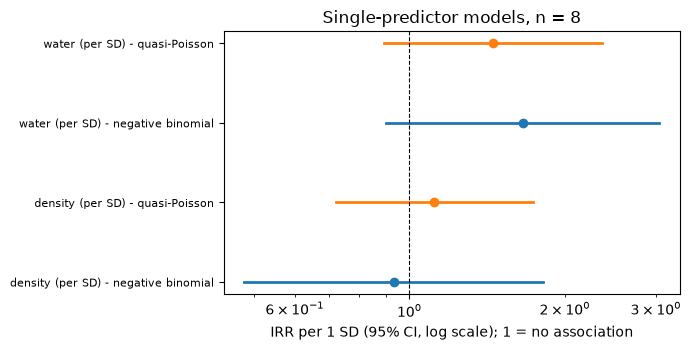

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.6))
plot_rows = irr_all[irr_all['model'] != 'density + water'].reset_index(drop=True)
for i, r in plot_rows.iterrows():
    color = 'tab:blue' if r['family'] == 'negative binomial' else 'tab:orange'
    ax.plot([r['ci_low'], r['ci_high']], [i, i], color=color, lw=2)
    ax.plot(r['IRR'], i, 'o', color=color)
ax.axvline(1, color='black', lw=0.8, ls='--')
ax.set_yticks(range(len(plot_rows))); ax.set_yticklabels([f"{r['predictor']} - {r['family']}" for _, r in plot_rows.iterrows()], fontsize=8)
ax.set_xscale('log'); ax.set_xlabel('IRR per 1 SD (95% CI, log scale); 1 = no association')
ax.set_title('Single-predictor models, n = 8'); plt.tight_layout(); plt.show()

## 6. Residual spatial autocorrelation (the H9 gate)

If the model left spatial structure in its residuals, its standard errors are
still too optimistic and a predictor is probably missing. Moran's I is computed on
the **negative-binomial** residuals for every model, and -- because the answer
depends on how "residual" is defined and I do not want to report only the flattering
cell -- for three definitions:

- **Pearson** (observed - fitted, scaled by the model's SD),
- **deviance**, and
- **log(observed / fitted)**, the plain multiplicative miss, which is *not*
  weighted by population.

The full grid is shown; nothing is picked out. 12 tests on 8 units is itself a
multiple-comparisons hazard, so treat individual p-values as descriptive.

In [9]:
rows = []
for name in FORMULAS:
    nb = fits[name]['nb']
    residuals = {
        'Pearson': nb.resid_pearson.values,
        'deviance': nb.resid_deviance.values,
        'log(obs/fitted)': np.log(data['cases'].values / nb.fittedvalues.values),
    }
    row = {'model (NB)': name}
    for kind, res in residuals.items():
        m = residual_moran(res, weights)
        row[kind] = f"I={m.I:+.2f}, p={m.p_sim:.3f}"
    rows.append(row)
pd.DataFrame(rows).set_index('model (NB)')

,Pearson,deviance,log(obs/fitted)
model (NB),,,
null (rate only),"I=+0.32, p=0.013","I=+0.19, p=0.074","I=+0.08, p=0.144"
density,"I=+0.30, p=0.022","I=+0.17, p=0.089","I=+0.06, p=0.163"
water,"I=-0.03, p=0.288","I=-0.17, p=0.485","I=-0.18, p=0.399"
density + water,"I=-0.03, p=0.294","I=-0.16, p=0.487","I=-0.18, p=0.403"


## 7. Leave-one-out: how much does one division drive the water estimate?

With n = 8 any single division can dominate. The water-model IRR (quasi-Poisson,
which needs no extra parameter) refitted with each division removed in turn.

In [10]:
rows = []
for drop in data['division']:
    sub = data[data['division'] != drop].copy()
    sub['z_water'] = standardize(sub['water_occ'])
    t = irr_table(fit_count_model(sub, 'cases ~ z_water', 'population', 'quasi-poisson')).loc['z_water']
    rows.append({'dropped': drop, 'IRR per SD water': round(t['IRR'], 2), '95% CI': f"{t['ci_low']:.2f}-{t['ci_high']:.2f}", 'p': round(t['p'], 3)})
loo = pd.DataFrame(rows).set_index('dropped')
print(loo.to_string())
print(f"range of IRR when dropping one division: {loo['IRR per SD water'].min()} to {loo['IRR per SD water'].max()}")

            IRR per SD water     95% CI      p
dropped                                       
Barisal                 1.28  0.76-2.16  0.357
Chittagong              1.49  0.80-2.75  0.208
Dhaka                   1.45  0.78-2.68  0.236
Khulna                  1.42  0.79-2.56  0.245
Mymensingh              1.47  0.83-2.59  0.182
Rajshani                1.41  0.83-2.41  0.201
Rangpur                 1.29  0.77-2.16  0.338
Sylhet                  1.94  1.53-2.47  0.000
range of IRR when dropping one division: 1.28 to 1.94


## 8. Limitations

Written to be read before any number above is quoted.

- **Ecological fallacy.** Every association here is between *division averages*.
  "Divisions with more surface water had ~X times the admission rate" does **not**
  mean water-exposed *people* are at higher risk, and says nothing about any
  individual, household or ward. Relationships at the person level can differ in
  size or even sign from the group-level one. These results cannot be used to
  target or prioritise sub-division areas.
- **MAUP (modifiable areal unit problem).** Divisions are large (10,000-30,000 km2)
  administrative shapes; different boundaries would give different numbers.
  Averaging water occurrence over a whole division hides the fact that dengue
  transmission is local (a breeding site and the people within ~100-400 m of it).
- **Admitted cases, attributed by hospital, not by home.** These are hospitalised
  patients, i.e. severity- and care-seeking-filtered, and (to be verified against DGHS
  documentation, not assumed) most likely assigned to the division of the
  reporting hospital. Dhaka's tertiary hospitals plausibly receive referrals from
  other divisions, which would inflate Dhaka's numerator against a resident-population
  denominator and deflate the others'. Sylhet's 277 admissions (2.3 per 100k; the next-lowest, Rangpur, is 10.3) may partly reflect this, or reporting completeness, not just lower transmission.
- **n = 8, year-to-date.** Two predictors is already at the edge; the confidence
  intervals are wide and every conclusion is provisional. 2026 to 20 Sept is a
  partial dengue season (peak is typically Aug-Oct), so this is one snapshot of an
  in-progress year, and the counts change daily.
- **Mismatched time bases.** Population is a 2020 modelled estimate (constrained
  WorldPop), water occurrence is 1984-2020, cases are 2026.
- **Small internal inconsistencies in the source.** DGHS's division chart and its
  division/city-corporation chart differ by a handful of cases (e.g. Chattogram
  8,671 vs 8,672; one chart has a 3-case "Raishahi" typo entry) -- <0.1% of the
  total, noted, not adjusted.
- **Residual-autocorrelation results are low-power and multiple looks.** See section 6.
- **Not done, and why.** *R-INLA / BYM spatial random effects*: 8 areas cannot
  support a spatial latent field (see scope note). *Space-time scan statistic
  (SaTScan-style)*: needs case locations or many small areas over time; the public
  data has 8 areas. DGHS also publishes a weekly-by-division series, which
  would allow a division-by-week panel later -- not attempted here.

## 9. What was found

**The H9 gate is met**: a fitted, dispersion-checked count model with a population
offset, coefficient interpretation, residual spatial autocorrelation checked, and
limitations written. The substantive answer, though, is a **null result**.

- **Poisson is invalid here** (Pearson dispersion 2,555-4,545 vs. ~1 expected).
  Divisions differ from each other far more than Poisson noise allows, so its
  razor-thin intervals were discarded. The negative-binomial dispersion is
  alpha ~ 0.7-0.8: between-division variation in rates is large.
- **Population density** (per SD of log density): IRR **0.93** (95% CI 0.48-1.82) in the
  NB model and **1.12** (0.72-1.73) quasi-Poisson -- the direction flips between families
  and every interval spans 1. No evidence of an association either way.
- **Surface-water occurrence** (per SD, roughly 4 percentage points of mean occurrence): IRR
  **1.66** (0.90-3.04) NB and **1.45** (0.89-2.35) quasi-Poisson. Read plainly: divisions
  with a higher water share had an admission rate roughly 45-65% higher per SD, *but* the
  interval includes "no effect" (p = 0.11 and 0.13). It is a consistent direction across
  both families, not an established finding. Adding density changes nothing
  (water IRR 1.67 / 1.46).
- **Residual autocorrelation**: the raw pattern is not significantly clustered (Moran's I
  of log crude incidence = 0.08, p = 0.14). Models *without* water leave Pearson-residual
  autocorrelation of I ~ +0.3 (p = 0.013 null, 0.022 density-only; deviance residuals
  p = 0.07-0.09; the unweighted log-ratio residuals are not significant, p = 0.14-0.16):
  the south-central divisions (Barisal, Khulna, Dhaka) run higher than a uniform-rate
  model expects. Once water occurrence is in the model, all residual Moran's I values
  fall to about zero or negative (p >= 0.29 on every definition). That is *consistent*
  with water occurrence absorbing a real regional pattern -- but with 8 units it
  cannot be told apart from water simply being a marker of delta geography or of how
  divisions report. Residual autocorrelation being absent is also weak evidence at
  this n.
- **Sylhet drives the water estimate.** It has the highest water occurrence of any division (14.9%)
  and by far the lowest admission rate (2.3 per 100k). Dropping Sylhet raises the
  water IRR to 1.94 (1.53-2.47); dropping any other division gives 1.28-1.49. That
  leave-one-out is a diagnostic. It is **not** a licence to exclude Sylhet: deciding
  to drop it after seeing the result is exactly the forking-path move that produces
  false positives, and its 7-unit "p < 0.001" should not be quoted. Whether Sylhet's
  low count is real, a referral/reporting artefact, or something else is unresolved.

**Bottom line**: with the only real public dengue geography (8 divisions), no
satellite/population predictor tested is statistically distinguishable from no
effect, and the data cannot support a spatial risk model. The negative result is
the finding: division-level admission counts are too coarse and too few to test
what the project's satellite predictors were built to test.

**Consequence for later phases.** H10 as specified (a ward-level risk score,
back-tested on a held-out season) needs ward- or upazila-level counts over more
than one season. Nothing public provides that; it needs either a data-sharing
request to DGHS/IEDCR, or a reformulation on what does exist. The H10 plan should be
revisited before any modelling starts, rather than producing a ward "risk map" from
data that does not support one.